# 🤬 Project 3: Triaging Toxicity ⚗️
##### Author: Mike Ee, [mikeee.co](https://mikeee.co)

Research Question
> How toxic is a comment?

## Table of Contents

1. [Background](#background)
2. [Load Data](#data)
3. [Exploratory Data Analysis](#eda)
4. [Methodology](#methodology)
5. [Predictive Modelling](#modelling)
    * 5.5 [Transformer Comparison: DistilBERT](#distilbert)
6. [Conclusion](#conclusion)
7. [References & Acknowledgements](#ref)

<a id="background"></a>
## 1. Background

Online platforms receive far more user comments than human moderators can review. This project builds a <b>binary classifier</b> that flags toxic comments so that moderation effort can be prioritised.

<u>About the dataset</u> The Civil Comments dataset archives public comments posted from 2015 to 2017 on about 50 English-language news sites through the Civil Comments commenting plugin, released as an open archive when the platform shut down in 2017. Jigsaw added crowd-rated toxicity scores, and the data mirrors the Jigsaw Unintended Bias in Toxicity Classification Kaggle challenge. The file used here, `train-00000-of-00002.parquet`, holds 902,437 comments: a `text` column and seven continuous scores from 0 to 1 (`toxicity`, `severe_toxicity`, `obscene`, `threat`, `insult`, `identity_attack`, `sexual_explicit`). It is released under the CC0 licence.

<a id="data"></a>
## 2. Load Data

### 2.1 Setup

In [1]:
from IPython.core.display import HTML
table_css = 'table {align:left;display:block} '
HTML('<style>{}</style>'.format(table_css))

<style>
/* ---------- CAPTIONS ---------- */
.fig-caption {
    background-color: #f4f4f4;
    color: #1e1e1e;              
    border-left: 4px solid #1e1e1e;
    padding: 8px 12px;
    margin-top: -4px;            
    font-size: 0.9em;
    font-style: italic;
}

/* ------- SECTION HEADERS ------ */
.section-header {
    border-bottom: 2px solid #ccc;
    padding-bottom: 4px;
    margin-top: 30px;
}

/* ---------- CALLOUTS ---------- */
.section-callout {
    background-color: #fff8e1;
    color: #1e1e1e;              
    border: 1px solid #ffca28;
    border-radius: 4px;
    padding: 10px 14px;
    margin: 10px 0;
    font-size: 14px;             
}

/* ------- CALLOUT HEADING ------ */
.section-callout h4 {
    margin-top: 0;               
    margin-bottom: 8px;          
}

/* ------ CALLOUT TABLES ------- */
.section-callout table {
    border: none;                
    background: transparent;     
    width: 100%;                 
    table-layout: fixed;         
}
.section-callout td {
    border: none;                
    padding: 4px 8px;
    text-align: left;            
    vertical-align: top;         
}

/* ----w-- CALLOUT IMAGES ------ */
.section-callout img {
    max-width: 100%;             
    height: auto;                
}

/* ------- CALLOUT LISTS ------ */
.section-callout ul {
    margin: 10;                  
    padding-left: 18px;         
}
.section-callout li {
    margin-bottom: 6px;         
}
</style>

In [2]:
pip install pandas pyarrow

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install spacy

Note: you may need to restart the kernel to use updated packages.


In [5]:
import sys                                            
!{sys.executable} -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 12.8/12.8 MB 91.4 MB/s  0:00:00
[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [6]:
pip install -q transformers datasets torch accelerate scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [7]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer

import time                                   
import spacy  
nlp = spacy.load("en_core_web_sm")      

from pathlib import Path                        

from sklearn.linear_model import LogisticRegression   
from sklearn.naive_bayes import MultinomialNB          
from sklearn.svm import LinearSVC                       
from sklearn.base import clone                          

import scipy.sparse as sp                               

from sklearn.metrics import (classification_report, balanced_accuracy_score,
                             f1_score, ConfusionMatrixDisplay, roc_auc_score,
                             roc_curve, auc, make_scorer, f1_score)

from sklearn.pipeline import Pipeline

from wordcloud import WordCloud 

from matplotlib import font_manager as fm
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\micha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
# Colour palette
GREEN       = "#8A9A5B"
GREEN_LIGHT = "#B5C08A"
GREEN_DARK  = "#6E7B45"
MAROON      = "#7B2D26"   # toxic
INK         = "#1A1A1A"   # near-black text
GREY        = "#C7C7C7"   # muted gridlines

# a green sequential colormap so heatmaps/gradients match too
plex_green = LinearSegmentedColormap.from_list(
    "plex_green", ["#F4F6EC", GREEN, GREEN_DARK])          # light to olive to deep
plex_maroon = LinearSegmentedColormap.from_list(
    "plex_maroon", ["#F6ECEB", "#B96A61", MAROON])         # light to brick to maroon
mpl.colormaps.register(plex_green, force=True)             # callable as cmap="plex_green"
mpl.colormaps.register(plex_maroon, force=True)

# Font: IBM Plex Sans (open-source OFL)
for ttf in Path("fonts").glob("IBMPlexSans*.ttf"):
    fm.fontManager.addfont(str(ttf))
try:
    fm.findfont("IBM Plex Sans", fallback_to_default=False) 
    FONT_STACK = ["IBM Plex Sans", "DejaVu Sans"]           # Plex first, safe fallback second
except ValueError:
    FONT_STACK = ["DejaVu Sans"]
    print("IBM Plex Sans not found — falling back. See the setup note above to install it.")

# Global rcParams for all plots
plt.rcParams.update({
    # type
    "font.family":       FONT_STACK,   
    "font.size":         11,
    "axes.titlesize":    14,
    "axes.titleweight":  "bold",
    "figure.titlesize":  16,
    "text.color":        INK,
    "axes.labelcolor":   INK,
    "xtick.color":       INK,
    "ytick.color":       INK,

    # colour cycle: green = civil, maroon = toxic
    "axes.prop_cycle":   mpl.cycler(color=[GREEN, MAROON, GREEN_LIGHT,
                                           GREEN_DARK, GREY, INK]),

    # styling
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.edgecolor":    GREY,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#ECECEC",
    "grid.linewidth":    0.8,
    "image.cmap":        "plex_green",

    # export settings
    "savefig.dpi":       200,
    "savefig.bbox":      "tight",
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
})
print(f"House style loaded · font = {FONT_STACK[0]}")

House style loaded · font = IBM Plex Sans


In [10]:
# save all plots
FIGDIR = Path("figures"); FIGDIR.mkdir(exist_ok=True)
_orig_show = plt.show
_counter   = {"n": 0}
def _show_and_save(*args, **kwargs):
    _counter["n"] += 1
    plt.gcf().savefig(FIGDIR / f"plot_{_counter['n']:02d}.png")
    return _orig_show(*args, **kwargs)                       # display as normal
plt.show = _show_and_save

### 2.2 Load dataset

In [11]:
df = pd.read_parquet('train-00000-of-00002.parquet')
df

,text,toxicity,severe_toxicity,obscene,threat,insult,identity_attack,sexual_explicit
0,"This is so cool. It's like, 'would you want yo...",0.000000,0.000000,0.0,0.0,0.00000,0.000000,0.0
1,Thank you!! This would make my life a lot less...,0.000000,0.000000,0.0,0.0,0.00000,0.000000,0.0
2,This is such an urgent design problem; kudos t...,0.000000,0.000000,0.0,0.0,0.00000,0.000000,0.0
3,Is this something I'll be able to install on m...,0.000000,0.000000,0.0,0.0,0.00000,0.000000,0.0
4,haha you guys are a bunch of losers.,0.893617,0.021277,0.0,0.0,0.87234,0.021277,0.0
...,...,...,...,...,...,...,...,...
902432,We Alaskans are at a fork in the road; we can ...,0.000000,0.000000,0.0,0.0,0.00000,0.000000,0.0
902433,Fix the broken oil and gas system that prices ...,0.300000,0.000000,0.0,0.0,0.30000,0.000000,0.0
902434,It's just a mindless slogan. A display of chil...,0.400000,0.000000,0.0,0.0,0.40000,0.000000,0.0
902435,"Poor Boots , reality is messing his mind up yu...",0.000000,0.000000,0.0,0.0,0.00000,0.000000,0.0


### 2.3 Preliminary checks

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 902437 entries, 0 to 902436
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   text             902437 non-null  object 
 1   toxicity         902437 non-null  float32
 2   severe_toxicity  902437 non-null  float32
 3   obscene          902437 non-null  float32
 4   threat           902437 non-null  float32
 5   insult           902437 non-null  float32
 6   identity_attack  902437 non-null  float32
 7   sexual_explicit  902437 non-null  float32
dtypes: float32(7), object(1)
memory usage: 31.0+ MB


In [13]:
df.describe()

,toxicity,severe_toxicity,obscene,threat,insult,identity_attack,sexual_explicit
count,902437.000000,902437.000000,902437.000000,902437.000000,902437.000000,902437.000000,902437.000000
mean,0.100712,0.004487,0.013968,0.009079,0.079431,0.021541,0.006683
std,0.194661,0.022698,0.065745,0.048827,0.173437,0.076345,0.045310
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.166667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,0.534819,1.000000,1.000000,1.000000,1.000000,1.000000


In [14]:
df.isnull().sum()

text               0
toxicity           0
severe_toxicity    0
obscene            0
threat             0
insult             0
identity_attack    0
sexual_explicit    0
dtype: int64

In [15]:
df.isnull().mean() * 100

text               0.0
toxicity           0.0
severe_toxicity    0.0
obscene            0.0
threat             0.0
insult             0.0
identity_attack    0.0
sexual_explicit    0.0
dtype: float64

In [16]:
# checking for common sentinel values (missing unknown)
for sentinel in [-1, 999, -999]:            
    print(sentinel, (df == sentinel).sum())

-1 text               0
toxicity           0
severe_toxicity    0
obscene            0
threat             0
insult             0
identity_attack    0
sexual_explicit    0
dtype: int64
999 text               0
toxicity           0
severe_toxicity    0
obscene            0
threat             0
insult             0
identity_attack    0
sexual_explicit    0
dtype: int64
-999 text               0
toxicity           0
severe_toxicity    0
obscene            0
threat             0
insult             0
identity_attack    0
sexual_explicit    0
dtype: int64


In [17]:
# examining columns
for col in df.columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().sort_index())


--- text ---


text
! save it commy,, china is evil, repressive anti freedom  evil.                                                                                                                                                                                    1
!!\nA better explanation of it for sure.\n\nBad news though...the Catou1403  fund is closed to new investors at the moment :)                                                                                                                      1
!!\nMany may see your analogy clearly, but I suspect you will not get many (no longer anonymous) likes...\nPart of Ms Wente's  point is made...the silent majority (OK 49%) did not want to openly support Trump but did so in a polling booth.    1
!!!                                                                                                                                                                                                                                                1
!!!\nI hear ENB

In [18]:
df.head(10)

,text,toxicity,severe_toxicity,obscene,threat,insult,identity_attack,sexual_explicit
0,"This is so cool. It's like, 'would you want yo...",0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
1,Thank you!! This would make my life a lot less...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
2,This is such an urgent design problem; kudos t...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
3,Is this something I'll be able to install on m...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
4,haha you guys are a bunch of losers.,0.893617,0.021277,0.000000,0.0,0.872340,0.021277,0.000000
5,ur a sh*tty comment.,0.666667,0.047619,0.638095,0.0,0.333333,0.000000,0.009524
6,hahahahahahahahhha suck it.,0.457627,0.050847,0.305085,0.0,0.254237,0.000000,0.220339
7,FFFFUUUUUUUUUUUUUUU,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
8,The ranchers seem motivated by mostly by greed...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
9,It was a great show. Not a combo I'd of expect...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000


In [19]:
df.tail(10)

,text,toxicity,severe_toxicity,obscene,threat,insult,identity_attack,sexual_explicit
902427,Where are these thousands of jobs that pay doc...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
902428,You sir are part of the problem. You will find...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
902429,Some of them will work without fall protection...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
902430,The decision not to raise the flamingo pole is...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
902431,"Her article sounds nice, but what about the gu...",0.000000,0.0,0.0,0.0,0.0,0.0,0.0
902432,We Alaskans are at a fork in the road; we can ...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
902433,Fix the broken oil and gas system that prices ...,0.300000,0.0,0.0,0.0,0.3,0.0,0.0
902434,It's just a mindless slogan. A display of chil...,0.400000,0.0,0.0,0.0,0.4,0.0,0.0
902435,"Poor Boots , reality is messing his mind up yu...",0.000000,0.0,0.0,0.0,0.0,0.0,0.0
902436,"""It's going to be a great healthcare bill and ...",0.166667,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
# examining a random sample of 150,000 rows
df_sample = df.sample(n=150_000, random_state=42)
print(df["toxicity"].describe())      # min/max/quartiles of continuous score 
print((df["toxicity"] >= 0.5).mean()) # proportion above conventional cut

count    902437.000000
mean          0.100712
std           0.194661
min           0.000000
25%           0.000000
50%           0.000000
75%           0.166667
max           1.000000
Name: toxicity, dtype: float64
0.07773285004936632


#### 2.3.1 Observations
* No null or sentinel values (`-1`, `999`, `-999`) appear in any of the eight columns.
* `toxicity` is heavily right-skewed: the median is 0, and only 7.8% of comments score 0.5 or higher. This threshold, the convention in the Jigsaw challenge, defines the binary `label` in Section 3.

<a id="eda"></a>
## 3. Exploratory Data Analysis

### 3.1 Stratified sample of 150,000 comments
`toxicity` is binarised at 0.5 into `label`, and a stratified sample keeps the 92:8 civil-to-toxic ratio while keeping lemmatisation time manageable.

In [21]:
# create discrete label from continuous score
df["label"] = (df["toxicity"] >= 0.5).astype(int)

# split to 150,000 base size
df_base, _ = train_test_split(
    df,                        
    train_size=150_000,       
    stratify=df["label"],      
    random_state=42
)

# verification check
print(f"Population Distribution [n is {len(df)}]: {df["label"].value_counts(normalize=True)}")
print(f"\ndf_base Distribution [n is {len(df_base)}]: {df_base["label"].value_counts(normalize=True)}")

Population Distribution [n is 902437]: label
0    0.922267
1    0.077733
Name: proportion, dtype: float64

df_base Distribution [n is 150000]: label
0    0.922267
1    0.077733
Name: proportion, dtype: float64


In [22]:
df_base.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 488019 to 378852
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   text             150000 non-null  object 
 1   toxicity         150000 non-null  float32
 2   severe_toxicity  150000 non-null  float32
 3   obscene          150000 non-null  float32
 4   threat           150000 non-null  float32
 5   insult           150000 non-null  float32
 6   identity_attack  150000 non-null  float32
 7   sexual_explicit  150000 non-null  float32
 8   label            150000 non-null  int64  
dtypes: float32(7), int64(1), object(1)
memory usage: 7.4+ MB


### 3.2 Toxicity subtypes, comment length and class imbalance

C:\Users\micha\AppData\Local\Temp\ipykernel_45308\1163704404.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=label_counts.values,
findfont: Failed to find font weight bold, now using 400.


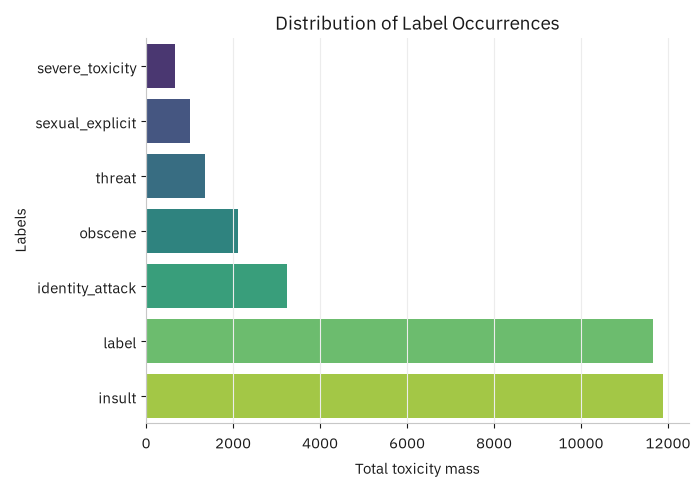

In [23]:
# Visualizing the class distribution of the 'label' column
column_labels = df_base.columns.tolist()[2:]
label_counts = df_base[column_labels].sum().sort_values()

# setup plot
plt.figure(figsize=(7, 5))

# Create a horizontal bar plot using Seaborn
ax = sns.barplot(x=label_counts.values,
                 y=label_counts.index, palette='viridis')


# Add labels and title to the plot
plt.xlabel('Total toxicity mass')
plt.ylabel('Labels')
plt.title('Distribution of Label Occurrences')

# Show the plot
plt.show()

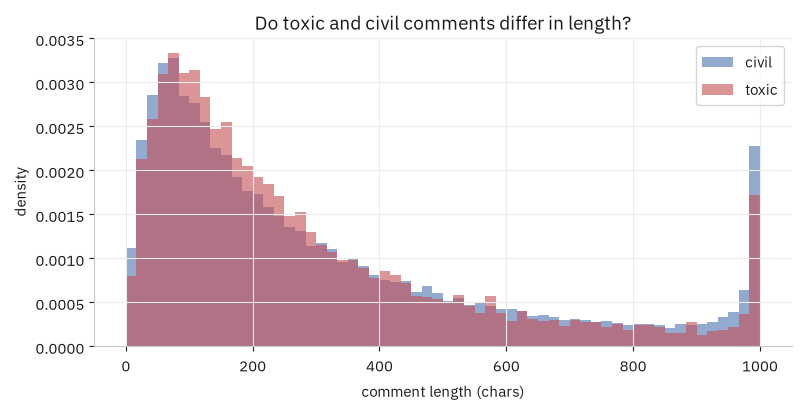

In [24]:
# plot length distribution by class
df_base["n_chars"] = df_base["text"].str.len()            # raw length as a quick proxy feature
fig, ax = plt.subplots(figsize=(9, 4))
for lab, colour in [(0, "#4c72b0"), (1, "#c44e52")]:
    ax.hist(df_base.loc[df_base["label"]==lab, "n_chars"],
            bins=60, range=(0, 1000), alpha=0.6,           # cap at 1000 chars to see the mass
            density=True, label={0:"civil",1:"toxic"}[lab], color=colour)
ax.set_xlabel("comment length (chars)"); ax.set_ylabel("density")
ax.set_title("Do toxic and civil comments differ in length?"); ax.legend()
plt.show()

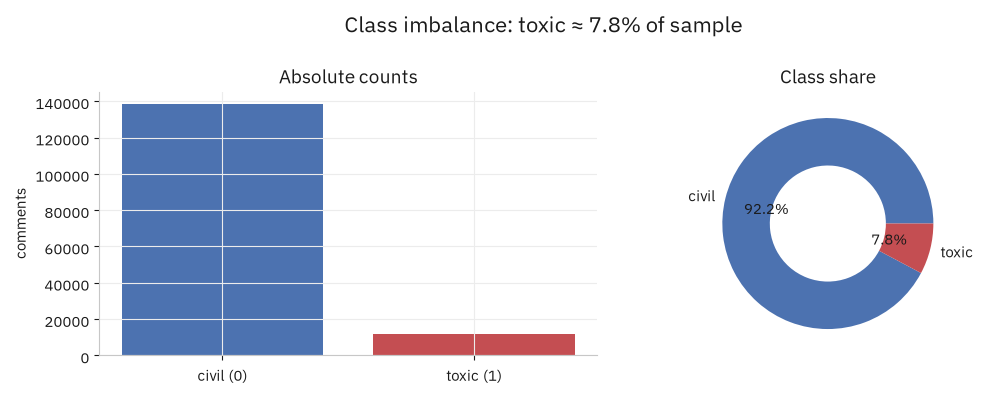

In [25]:
# plot of binary class imbalance 
fig, ax = plt.subplots(1, 2, figsize=(11, 4))            
counts = df_base["label"].value_counts().sort_index()     # 0 = civil, 1 = toxic
ax[0].bar(["civil (0)", "toxic (1)"], counts.values,      # raw counts
          color=["#4c72b0", "#c44e52"])
ax[0].set_title("Absolute counts"); ax[0].set_ylabel("comments")
ax[1].pie(counts.values, labels=["civil", "toxic"],       # share of total
          autopct="%1.1f%%", colors=["#4c72b0", "#c44e52"],
          wedgeprops=dict(width=0.45))                     # donut = less ink, more editorial
ax[1].set_title("Class share")
fig.suptitle(f"Class imbalance: toxic ≈ {counts[1]/counts.sum():.1%} of sample")
plt.tight_layout(); plt.show()

#### 3.2.1 Observations
* `insult` carries almost as much toxicity mass as `label` itself, followed by `identity_attack`; `severe_toxicity` is the rarest subtype.
* Toxic and civil comments overlap closely in length (the spike at 1,000 characters is the plot cap), so length alone is a weak signal.
* Toxic comments make up 7.8% of the sample, so accuracy would reward a model that never flags anything.

### 3.3 Stopword curation with the Natural Language Toolkit (NLTK)
Standard stopword lists remove pronouns, negations and intensifiers that may carry toxic intent, so these candidates are tested before removal.

In [26]:
nltk_stops = set(stopwords.words("english"))   

# group by linguistic function
candidate_groups = {                             
    "pronoun_2p":   ["you", "your", "yours", "yourself"],      # 2nd person: direct address / targeting
    "pronoun_3p":   ["they", "them", "their", "theirs"],       # 3rd person: out-grouping / disassociation
    "negation":     ["not", "no", "nor", "never", "cannot"],   # polarity 
    "intensifier":  ["very", "most", "too", "so", "such", "more"],  # degree
}

candidates = sorted({w for grp in candidate_groups.values() for w in grp})

### 3.4 Document frequency ratio (lift) of candidate stopwords

In [27]:
# transform text into document-term matrix using CountVec
vec = CountVectorizer(
    vocabulary=candidates,   # limit to candidates
    binary=True,             # binary=True → presence/absence (i.e. documents frequency)
    lowercase=True           
)
# sparse matrix, shape (n_docs, n_candidates)
X = vec.fit_transform(df_base["text"])          

# convert series to plain numpy bool array for scipy indexing
is_tox = (df_base["label"] == 1).to_numpy()       
is_civ = ~is_tox             # civility as counter to toxicity

# column mean over toxic rows = P(word appears | toxic/civil)
tox_rate   = np.asarray(X[is_tox].mean(axis=0)).ravel()   
civil_rate = np.asarray(X[is_civ].mean(axis=0)).ravel()   

# ratio; epsilon guards divide-by-zero on rare words
lift = (tox_rate + 1e-9) / (civil_rate + 1e-9)  

In [28]:
# thresholds for sorting
lift_min   = 1.30            # ≥ 1.3 = toxic-skew 
lift_max   = 1/1.30          # ≤ 0.77 = civil-skew
min_docs   = 500             # coverage floor: word must appear in ≥500 comments total, or the rate is noise

# tabulate vectorised text
gap = (
    pd.DataFrame({                                        
        "term":       vec.get_feature_names_out(),       # column order from fitted vectoriser
        "tox_rate":   tox_rate,
        "civil_rate": civil_rate,
        "n_docs":     np.asarray(X.sum(axis=0)).ravel(),  # symmetric scale: 0 = no signal, ± = direction
    })
    .assign(                                              
        lift       = lambda d: (d["tox_rate"] + 1e-9) / (d["civil_rate"] + 1e-9),
        log_lift   = lambda d: np.log2(d["lift"]),        # column sum = number of docs containing word
        abs_signal = lambda d: d["log_lift"].abs(),       
        direction  = lambda d: np.where(d["log_lift"] > 0, "toxic_skew", "civil_skew"),
        decision   = lambda d: np.select(
            [
                d["n_docs"] < min_docs,                              
                (d["lift"] >= lift_min) | (d["lift"] <= lift_max),
            ],
            ["Drop as insufficient evidence", "Keep as class signal"],
            default="Drop as no meaningful gap"
        ),
    )
    .sort_values("abs_signal", ascending=False)           # highest toxic-skew at top
    .reset_index(drop=True)
)

keep_list = set(gap.loc[gap["decision"].str.startswith("Keep"), "term"])

# record final stop words
final_stopwords = nltk_stops - keep_list

In [29]:
gap

,term,tox_rate,civil_rate,n_docs,lift,log_lift,abs_signal,direction,decision
0,yourself,0.017067,0.010185,1608,1.675681,0.744747,0.744747,toxic_skew,Keep as class signal
1,very,0.040137,0.054713,8037,0.733595,-0.446944,0.446944,civil_skew,Keep as class signal
2,nor,0.006604,0.008985,1320,0.734969,-0.444245,0.444245,civil_skew,Keep as class signal
3,your,0.173413,0.130049,20013,1.333445,0.415158,0.415158,toxic_skew,Keep as class signal
4,theirs,0.001458,0.001157,177,1.260602,0.334113,0.334113,toxic_skew,Drop as insufficient evidence
5,you,0.377444,0.309368,47199,1.220049,0.286939,0.286939,toxic_skew,Drop as no meaningful gap
6,such,0.040309,0.033244,5069,1.212505,0.277991,0.277991,toxic_skew,Drop as no meaningful gap
7,not,0.245969,0.287545,42647,0.855410,-0.225311,0.225311,civil_skew,Drop as no meaningful gap
8,cannot,0.012693,0.014717,2184,0.862448,-0.213490,0.213490,civil_skew,Drop as no meaningful gap
9,more,0.110978,0.126688,18820,0.875993,-0.191009,0.191009,civil_skew,Drop as no meaningful gap


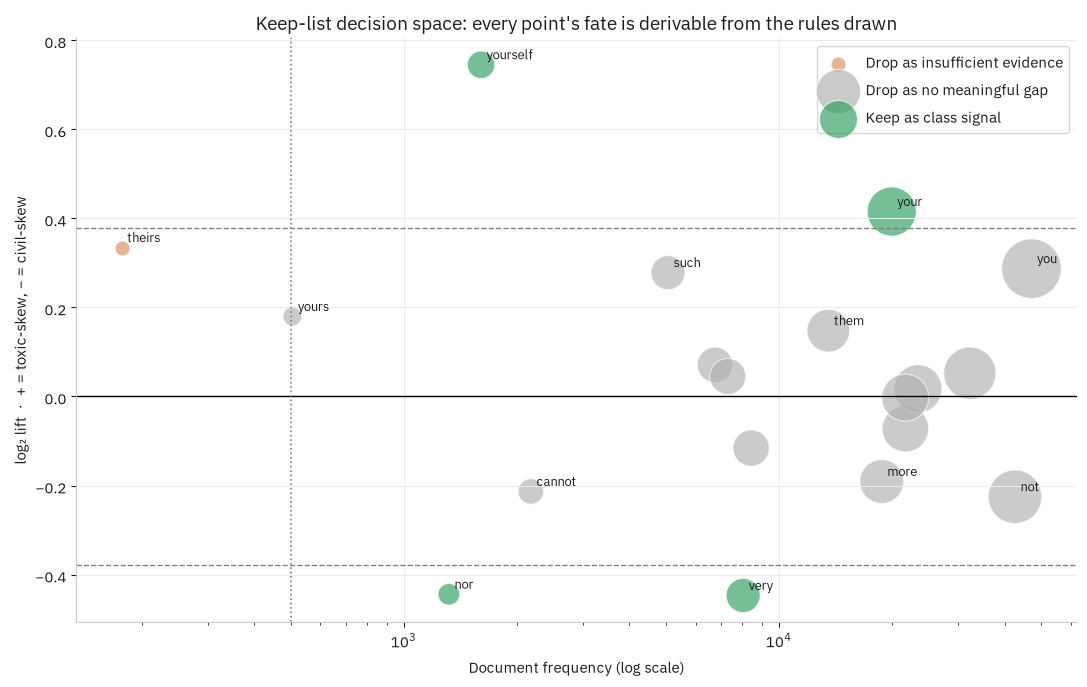

In [30]:
# plot stopwords as scatter bubble
fig, ax = plt.subplots(figsize=(11, 7))

palette = {                                   
    "Keep as class signal":          "#2a9d5c",   # green
    "Drop as no meaningful gap":     "#b0b0b0",   # grey
    "Drop as insufficient evidence": "#d98c5f",   # warm hue flags "failed on evidence", not "failed on signal"
}

# loop per category
for label, sub in gap.groupby("decision"):     
    ax.scatter(
        sub["n_docs"],
        sub["log_lift"],
        s=np.sqrt(sub["tox_rate"]) * 3000,     # sqrt() before scaling: area ∝ value
        c=palette[label],
        alpha=0.65,                            
        edgecolors="white", linewidth=0.8,     
        label=label
    )

ax.set_xscale("log")                           # log doc frequencies as power-law skewed                       
ax.axhline(0, color="black", lw=1)                                    # zero = no class signal
ax.axhline(np.log2(lift_min), color="grey", ls="--", lw=1)            # rescue threshold
ax.axhline(np.log2(lift_max), color="grey", ls="--", lw=1)            # lower (civil-skew) threshold
ax.axvline(min_docs, color="grey", ls=":", lw=1.2)                    # coverage floor

for _, r in gap.head(12).iterrows():           # annotate  strongest signals
    ax.annotate(r["term"], (r["n_docs"], r["log_lift"]),
                fontsize=9, xytext=(4, 4), textcoords="offset points")

ax.set_xlabel("Document frequency (log scale)")
ax.set_ylabel("log₂ lift  ·  + = toxic-skew, − = civil-skew")
ax.set_title("Keep-list decision space: every point's fate is derivable from the rules drawn")
ax.legend(frameon=True, loc="upper right")
plt.tight_layout()
plt.show()

#### 3.4.1 Observations
* Four candidates clear both the lift threshold (1.3 or 1/1.3) and the 500-comment coverage floor, so they are kept as class signals rather than removed: "yourself" and "your" skew toxic (direct address), while "very" and "nor" skew civil.
* "theirs" shows a lift of 1.26 but appears in only 177 comments, so it is dropped for insufficient evidence.

<a id="methodology"></a>
## 4. Methodology

Each comment passes through two cleaning pipelines, and each output is vectorised two ways, giving four document-term matrices:

| | Pipeline A: `light_tokens` | Pipeline B: `lemma_tokens` |
|--|--|--|
| Cleaning | Regular expression (regex) tokeniser with the curated stopword list from 3.4 | spaCy lemmatisation with spaCy's stopword list |
| Count (bag-of-words) | `count_light` | `count_lemma` |
| Term Frequency–Inverse Document Frequency (TF-IDF) | `tfidf_light` | `tfidf_lemma` |

Three linear classifiers, Logistic Regression (LogReg), Linear Support Vector Classifier (LinearSVC) and Multinomial Naive Bayes (MultinomialNB), are tuned on each matrix, giving 12 pipelines. Because toxic comments are rare, the primary metric is the <b>toxic-class F1 score</b> (toxic-F1). DistilBERT, a transformer that reads raw text in context, is then benchmarked on the same test rows.

### 4.1 Dynamic dispatcher for two cleaning pipelines

In [31]:
def clean(texts, method):                          
    """
    Stateless column-level text cleaner which returns list-of-token-lists. 
    Texts: iterable series of raw strings
    Methods: 'light' | 'lemma' 
    """

# pipeline A: light regex tokenisation with curated stopword removal
    if method == "light":                          
        tokenizer = RegexpTokenizer(r"[a-z']+")    # letters + apostrophes; strip digits/punctuation
        return [                                   # outer list = one entry per document
            [t for t in tokenizer.tokenize(str(doc).lower())   # str() guards against NaN/float cells
             if t not in final_stopwords]          
            for doc in texts
        ]
# pipeline B — spaCy lemmatisation
    elif method == "lemma":                        
        out = []                                   # accumulator; append per doc to keep order stable
        for i, doc in enumerate(nlp.pipe(          # batch-stream docs
            texts,                                 
            batch_size=64,                         # docs buffered p/batch
            n_process=1,                           
            disable=["parser", "ner"]              #  skip parse (analyse & structure human lang) + NER (categorise names)
        )):
            out.append([                           # inner list = tokens surviving this document
                token.lemma_.lower()               # str conversion
                for token in doc                   
                if not token.is_stop               
                and not token.is_punct             
                and not token.is_space             
                and token.lemma_.strip()           
            ])
            if i % 10000 == 0:                     # 💗
                print(f"  lemma: {i:,} docs...", flush=True)   # flush=True forces o/p
        return out

    else:
        raise ValueError(f"Unknown method: {method}")   

### 4.2 Running and caching both pipelines

In [32]:
# store last-run df_out 
CACHE = Path("tokens_both.parquet")             

if CACHE.exists():                              # .exists() returns last-run df_out
    df_out = pd.read_parquet(CACHE)             
    print(f"Loaded from cache: {len(df_out):,} rows")
else:                                           
# text cleaning    
    results, timings = {}, {}
    for method in ["light", "lemma"]:
        t0 = time.perf_counter()
        results[method] = clean(df_base["text"], method)
        timings[method] = time.perf_counter() - t0
# output df
    df_out = df_base.assign(
        light_tokens=results["light"],
        lemma_tokens=results["lemma"]
    )
# re-writes CACHE  
    df_out.to_parquet(CACHE, index=False)       
    print("Regenerated and cached")

Loaded from cache: 150,000 rows


In [33]:
df_out[df_out["label"] == 1].head(10)

,text,toxicity,severe_toxicity,obscene,threat,insult,identity_attack,sexual_explicit,label,light_tokens,lemma_tokens
9,"This dangerous person should be jailed for,lif...",0.636364,0.060606,0.045455,0.106061,0.651515,0.045455,0.015152,1,"[dangerous, person, jailed, life, discharged, ...","[dangerous, person, jail, life, discharge, dis..."
10,Have you considered that Trump has offered not...,0.600000,0.000000,0.600000,0.000000,0.200000,0.000000,0.200000,1,"[considered, trump, offered, single, damned, i...","[consider, trump, offer, single, damned, insta..."
15,Wow! Hot damn! This is just another example of...,0.500000,0.100000,0.500000,0.000000,0.100000,0.000000,0.000000,1,"[wow, hot, damn, another, example, walkers, dr...","[wow, hot, damn, example, walker, drunken, spe..."
18,"Hey pal, it's LGBTQ2S, not LGBTQQ2S - what sor...",0.651515,0.045455,0.045455,0.000000,0.560606,0.272727,0.015152,1,"[hey, pal, lgbtq, lgbtqq, sort, homophobic, mo...","[hey, pal, lgbtq2s, lgbtqq2s, sort, homophobic..."
26,Everyone in the West turned a blind eye to the...,0.500000,0.000000,0.200000,0.000000,0.400000,0.100000,0.000000,1,"[everyone, west, turned, blind, eye, horrible,...","[west, turn, blind, eye, horrible, working, co..."
36,"He crazy, reckless, out of control, etc. What ...",0.800000,0.000000,0.200000,0.000000,0.700000,0.100000,0.000000,1,"[crazy, reckless, control, etc, everyone, forg...","[crazy, reckless, control, etc, forget, people..."
60,the BS is coming fast and furious from Glamour...,0.600000,0.100000,0.200000,0.000000,0.300000,0.000000,0.300000,1,"[bs, coming, fast, furious, glamour, boy, cash...","[bs, come, fast, furious, glamour, boy, cash, ..."
69,"Oosterhoff: ""I'm not a homophobe but homosexu...",0.800000,0.100000,0.000000,0.000000,0.300000,0.800000,0.000000,1,"[oosterhoff, homophobe, homosexuality, sin, ga...","[oosterhoff, homophobe, homosexuality, sin, ga..."
82,You have the articulation skills of a stoned 1...,0.500000,0.100000,0.000000,0.000000,0.500000,0.000000,0.000000,1,"[articulation, skills, stoned, year, old, drop...","[articulation, skill, stone, 14, year, old, dr..."
99,"Of course not, don't be silly. Neither will G...",0.513514,0.013514,0.040541,0.000000,0.500000,0.000000,0.000000,1,"[course, silly, neither, gov, brown]","[course, silly, gov., brown]"


<div class="section-callout">
    <h4>4.2.1 🫖 Commentary 🍪</h4>
    <table>
        <tr>
            <td style="vertical-align: top; width: 30%; fontsize=14;">
            <ul>
            <li>Lemmatising the <code>text</code> column took 17.78 minutes, faster than the projected 22.3 minutes.</li>
            <li>Light cleaning took about 0.06 minutes. Whether lemmatisation justifies its extra cost is tested in 5.3.1.</li>
            <li>Both token columns are cached to <code>tokens_both.parquet</code>, so later runs skip this step.</li>
            </ul>
            </td>
            <td style="width: 70%;">
                <div style="display: flex; gap: 8px;">   <!-- flex = lay children in a row; gap = space between -->
                    <figure style="margin: 0; flex: 1;">   <!-- flex:1 = each figure takes equal share of the width -->
                      <img src="01_pipelineB_lemmatisation.png" style="width: 100%;">
                      <figcaption style="font-size: 12px;">Before: raw tokens</figcaption>
                    </figure>
                    <figure style="margin: 0; flex: 1;">
                        <img src="02_pipelineB_lemmatisation_done.png" style="width: 100%;">
                        <figcaption style="font-size: 12px;">After: lemmatised</figcaption>
                    </figure>
            </td>
        </tr>    
    </table>
</div>

### 4.3 Verifying the lemmatised DataFrame

In [34]:
df_lem = pd.read_parquet("tokens_both.parquet")   

# verify:
# i. shape
print(f"==== SHAPE ====")
print(df_lem.shape) 

# ii. index
print(f"\n==== INDEX ====")
print(df_lem.index.is_monotonic_increasing)        

# iii. token columns are objects
print(f"\n==== DTYPES ====")
print(df_lem.dtypes)              

# iv. positional access
print(f"\n==== SPECIFIC COLUMN ACCESS ====")
print(type(df_lem["lemma_tokens"].iloc[0]))        

# v. docs with 0-feature rows
print(f"\n==== DOCS WITH ZERO FEATURES ====")
empty_light = (df_lem["light_tokens"].str.len() == 0).sum()  # count of light tokens 
empty_lemma = (df_lem["lemma_tokens"].str.len() == 0).sum()  # count of lemma tokens (i.e. docs reduced to zero tokens)
print(empty_light, empty_lemma)                

==== SHAPE ====
(150000, 11)

==== INDEX ====
True

==== DTYPES ====
text                object
toxicity           float32
severe_toxicity    float32
obscene            float32
threat             float32
insult             float32
identity_attack    float32
sexual_explicit    float32
label                int64
light_tokens        object
lemma_tokens        object
dtype: object

==== SPECIFIC COLUMN ACCESS ====
<class 'numpy.ndarray'>

==== DOCS WITH ZERO FEATURES ====
231 348


In [35]:
# examining docs with zero features
mask_light_empty = df_lem["light_tokens"].str.len() == 0      
mask_lemma_empty = df_lem["lemma_tokens"].str.len() == 0      

# view gap rows first
mask_lemma_only = (~mask_light_empty) & mask_lemma_empty       
print(mask_lemma_only.sum())  

preview = df_lem.loc[mask_lemma_only, ["text", "light_tokens", "lemma_tokens"]]
with pd.option_context("display.max_colwidth", None, "display.max_rows", 30):
    print(preview.head(15))     

print(df_lem.loc[mask_lemma_only, "label"].value_counts())

144
                                        text            light_tokens  \
1245                              You first.                 [first]   
5118                    At least one ... :-/            [least, one]   
5402                   You might as well be.           [might, well]   
5762                            I always do.                [always]   
7352                        Are you serious?               [serious]   
7425                                Name it.                  [name]   
7821        Everyone else, all four of them?  [everyone, else, four]   
8750   One of the "few"? There you go again.               [one, go]   
9739                                    Move                  [move]   
10198                              Nor mine.                  [mine]   
10985   Neither did the one just above it...          [neither, one]   
11983                             Never was.                 [never]   
12206                  "never again" perhaps        [never, 

In [36]:
# drop union from both empty rows in pipeline A & B for comparative model consistency
mask_drop = (df_lem["light_tokens"].str.len() == 0) | (df_lem["lemma_tokens"].str.len() == 0)
print(f"==== EMPTY ROWS TO DROP ====")
print(mask_drop.sum())                        


# keep rows that are filled in either branch in df_model
df_model = df_lem.loc[~mask_drop].copy()
# new df_model shape
print(f"\n==== df_model SHAPE ====")
print(df_model.shape)          

# verify class balance maintained
print(f"\n==== CLASS BALANCE ====")
print(df_model["label"].value_counts(normalize=True))  

==== EMPTY ROWS TO DROP ====
375



==== df_model SHAPE ====
(149625, 11)

==== CLASS BALANCE ====
label
0    0.922072
1    0.077928
Name: proportion, dtype: float64


#### 4.3.1 Observations
* 375 comments left empty by either pipeline are dropped from both, so all four matrices share the same 149,625 rows, with the toxic share unchanged at 7.8%.

### 4.4 Word clouds: toxic versus civil comments

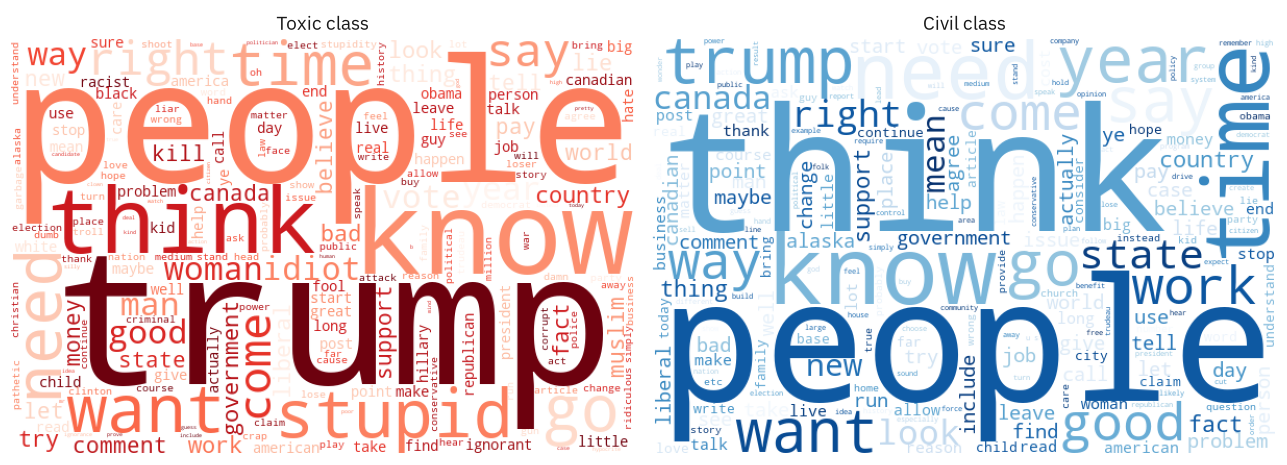

In [37]:
#plot toxic against civil word clouds

tox_tokens = df_model.loc[df_model["label"]==1, "lemma_tokens"]   # toxic docs' tokens
civ_tokens = df_model.loc[df_model["label"]==0, "lemma_tokens"]   # civil docs' tokens
tox_text = " ".join(t for toks in tox_tokens for t in toks)      # flatten list-of-lists to string
civ_text = " ".join(t for toks in civ_tokens for t in toks)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].imshow(WordCloud(width=600, height=400, background_color="white",
                       colormap="Reds").generate(tox_text)); ax[0].axis("off")
ax[0].set_title("Toxic class")
ax[1].imshow(WordCloud(width=600, height=400, background_color="white",
                       colormap="Blues").generate(civ_text)); ax[1].axis("off")
ax[1].set_title("Civil class")
plt.tight_layout(); plt.show()

### 4.5 Vectorising into four document-term matrices

In [38]:
# vectorise both token columns

# define token cols to prevent vectorisers from lowercasing & str-coercing 
def identity(tokens):
    return tokens

# fit four vectorisers with min matrix (>5 docs) size
vec_configs = {
    "count_light": CountVectorizer(analyzer=identity, min_df=5),
    "count_lemma": CountVectorizer(analyzer=identity, min_df=5),
    "tfidf_light": TfidfVectorizer(analyzer=identity, min_df=5),
    "tfidf_lemma": TfidfVectorizer(analyzer=identity, min_df=5),
}

# fit.transform learns vocab
X = {}
X["count_light"] = vec_configs["count_light"].fit_transform(df_model["light_tokens"].values)
X["count_lemma"] = vec_configs["count_lemma"].fit_transform(df_model["lemma_tokens"].values)
X["tfidf_light"] = vec_configs["tfidf_light"].fit_transform(df_model["light_tokens"].values)
X["tfidf_lemma"] = vec_configs["tfidf_lemma"].fit_transform(df_model["lemma_tokens"].values)

# evaluate text classifier method
print(f"==== EVALUATION OF TEXT CLASSIFIERS ====")
for name, matrix in X.items():
    print(f"{name:14s} shape={matrix.shape}  vocab={len(vec_configs[name].vocabulary_)}")

print(f"\n==== CLOSER LOOK ====")
# vocab size 
v_light = len(vec_configs["count_light"].vocabulary_)   
v_lemma = len(vec_configs["count_lemma"].vocabulary_)   

# what % of the regex vocab did lemma collapse?
reduction_pct = (v_light - v_lemma) / v_light * 100

print(f"light vocab:      {v_light:,}")         
print(f"lemma vocab:      {v_lemma:,}")
print(f"features removed: {v_light - v_lemma:,}")
print(f"reduction:        {reduction_pct:.1f}%") 

==== EVALUATION OF TEXT CLASSIFIERS ====
count_light    shape=(149625, 31017)  vocab=31017
count_lemma    shape=(149625, 24208)  vocab=24208
tfidf_light    shape=(149625, 31017)  vocab=31017
tfidf_lemma    shape=(149625, 24208)  vocab=24208

==== CLOSER LOOK ====
light vocab:      31,017
lemma vocab:      24,208
features removed: 6,809
reduction:        22.0%


#### 4.5.1 Observations
* Lemmatisation shrinks the vocabulary by 22.0%, from 31,017 to 24,208 terms, by merging word forms such as "idiot" and "idiots".

<a id="modelling"></a>
## 5. Predictive Modelling

### 5.1 Stratified train-test split on shared row indices
Splitting row positions (80:20, stratified) lets one split serve all four matrices and the DistilBERT benchmark.

In [39]:
# Split on positional indices, then reuse across all four matrices.
idx = np.arange(df_model.shape[0])         
y = df_model['label'].to_numpy()           

In [40]:
idx_train, idx_test, y_train, y_test = train_test_split(
    idx,                                    
    y,                                      
    test_size=0.2,                          # 80-20
    random_state=42,                        
    stratify=y                              # preserve class balance
)

### 5.2 Hyperparameter tuning with cross-validation
`GridSearchCV` tunes each of the 12 pipelines on the training set for toxic-F1, searching the vocabulary floor (`min_df`) and each classifier's regularisation (`C`) or smoothing (`alpha`) parameter.

In [41]:
# call evaluate() to unit-test pipelines separately
def evaluate(est, X_tr, y_tr, X_te, y_te):  # isolates the fit+score unit                  
    est.fit(X_tr, y_tr)
    pred = est.predict(X_te)
    return f1_score(y_te, pred, average='macro'), f1_score(y_te, pred, pos_label=1)

In [42]:
# passthrough analyser to prevent vectorisers from lowercasing & str-coercing 
def identity(x):                      
    return x                   

# toxicity tuner
toxic_f1 = make_scorer(f1_score, pos_label=1)   

# dict of token columns
branches = {                           
    'light': 'light_tokens',
    'lemma': 'lemma_tokens',
}

# ensures vectorisers are in GridCV
vectorisers = {
    'count': CountVectorizer(analyzer=identity),        # bag-of-words counts
    'tfidf': TfidfVectorizer(analyzer=identity),        # term frequency x inverse document frequency counts
}

# each classifier paired with valid grid for hyper-param tuning
models = {
    'LogReg': (LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
               {'clf__C': [0.1, 0.5, 1.0]}),          # C = regularisation
    'LinearSVC': (LinearSVC(random_state=42, class_weight='balanced', dual=False),
               {'clf__C': [0.1, 0.5, 1.0]}),          
    'MultinomialNB': (MultinomialNB(),
               {'clf__alpha': [0.1, 0.5, 1.0]}),      # alpha = smoothing (No C)
}

# shared vectoriser knob
vec_grid = {'vec__min_df': [5, 10, 20]}   # vocab floor: higher = fewer features = less overfit

# store tuned results
tuned = {}
for vec_name, vec in vectorisers.items():             # both vecs  
    for branch, col in branches.items():
        matrix  = f"{vec_name}_{branch}" 
        docs_tr = df_model[col].to_numpy()[idx_train]     # on train only
        for model_name, (est, clf_grid) in models.items():
            pipe = Pipeline([                             # rebuild p/model
                ('vec', clone(vec)),
                ('clf', est),
            ])
            grid = {**vec_grid, **clf_grid}               # merge shared min_df + model-specific knob
            s = GridSearchCV(pipe, grid, scoring=toxic_f1,
                             cv=3, n_jobs=-1, return_train_score=True)
            s.fit(docs_tr, y_train)
            tuned[(matrix, model_name)] = s
            print(f"{matrix:12s} | {model_name:13s} best {s.best_params_} -> toxic-F1 {s.best_score_:.4f}")

# comparison table
tuned_results = pd.DataFrame([
    {'matrix': m, 'model': mdl, 'branch': m.split('_')[1],
     'cv_toxic_f1': s.best_score_, **s.best_params_}
    for (m, mdl), s in tuned.items()
]).sort_values('cv_toxic_f1', ascending=False).reset_index(drop=True)
tuned_results

count_light  | LogReg        best {'clf__C': 0.1, 'vec__min_df': 5} -> toxic-F1 0.5477


count_light  | LinearSVC     best {'clf__C': 0.1, 'vec__min_df': 5} -> toxic-F1 0.5351


count_light  | MultinomialNB best {'clf__alpha': 0.5, 'vec__min_df': 5} -> toxic-F1 0.4680


count_lemma  | LogReg        best {'clf__C': 0.1, 'vec__min_df': 5} -> toxic-F1 0.5515


count_lemma  | LinearSVC     best {'clf__C': 0.1, 'vec__min_df': 5} -> toxic-F1 0.5327


...

tfidf_light  | MultinomialNB best {'clf__alpha': 0.1, 'vec__min_df': 5} -> toxic-F1 0.1520


tfidf_lemma  | LogReg        best {'clf__C': 1.0, 'vec__min_df': 5} -> toxic-F1 0.5465


tfidf_lemma  | LinearSVC     best {'clf__C': 0.1, 'vec__min_df': 5} -> toxic-F1 0.5484


tfidf_lemma  | MultinomialNB best {'clf__alpha': 0.1, 'vec__min_df': 5} -> toxic-F1 0.1647


,matrix,model,branch,cv_toxic_f1,clf__C,vec__min_df,clf__alpha
0,count_lemma,LogReg,lemma,0.551537,0.1,5,NaN
1,tfidf_lemma,LinearSVC,lemma,0.548435,0.1,5,NaN
2,count_light,LogReg,light,0.547704,0.1,5,NaN
3,tfidf_light,LinearSVC,light,0.546800,0.1,5,NaN
4,tfidf_lemma,LogReg,lemma,0.546458,1.0,5,NaN
5,tfidf_light,LogReg,light,0.543920,1.0,5,NaN
6,count_light,LinearSVC,light,0.535138,0.1,5,NaN
7,count_lemma,LinearSVC,lemma,0.532690,0.1,5,NaN
8,count_lemma,MultinomialNB,lemma,0.468758,NaN,10,1.0
9,count_light,MultinomialNB,light,0.467981,NaN,5,0.5


### 5.3 Evaluating tuned pipelines on the test set

In [43]:
# evaluate each tuned best_est on held-out test set
tuned_test_rows = []
for (matrix, model_name), s in tuned.items():
    branch  = matrix.split('_')[1]                                # 'light' | 'lemma'
    docs_te = df_model[f"{branch}_tokens"].to_numpy()[idx_test]   # test rows, raw tokens
    y_pred  = s.best_estimator_.predict(docs_te)                  # tuned pipeline vectorises + predicts
    tuned_test_rows.append({
        'matrix':   matrix,
        'model':    model_name,
        'f1_macro': f1_score(y_test, y_pred, average='macro'),
        'f1_toxic': f1_score(y_test, y_pred, pos_label=1),
    })
tuned_test_results = pd.DataFrame(tuned_test_rows).sort_values('f1_toxic', ascending=False).reset_index(drop=True)
tuned_test_results      

,matrix,model,f1_macro,f1_toxic
0,count_light,LogReg,0.761020,0.569804
1,count_lemma,LogReg,0.759102,0.567510
2,tfidf_lemma,LinearSVC,0.758094,0.567367
3,tfidf_light,LinearSVC,0.757774,0.565555
4,tfidf_lemma,LogReg,0.756205,0.564191
5,tfidf_light,LogReg,0.753487,0.558805
6,count_lemma,LinearSVC,0.753723,0.556323
7,count_light,LinearSVC,0.754284,0.555922
8,count_lemma,MultinomialNB,0.716672,0.485843
9,count_light,MultinomialNB,0.713397,0.479594


#### 5.3.1 Light versus lemma preprocessing

In [44]:
# evaluate text classifiers based on tuned_results
light_best = tuned_test_results[tuned_test_results['matrix'].str.endswith('light')]['f1_toxic'].max()  # best of count/tfidf light
lemma_best = tuned_test_results[tuned_test_results['matrix'].str.endswith('lemma')]['f1_toxic'].max()
delta = lemma_best - light_best
print(f"Tuned light {light_best:.4f} | tuned lemma {lemma_best:.4f} | Δ {delta:+.4f}")
print(f"ΔF1 per preprocessing-minute: {delta/17.72:+.4f}")    # 17.72 = lemma build overhead

Tuned light 0.5698 | tuned lemma 0.5675 | Δ -0.0023
ΔF1 per preprocessing-minute: -0.0001


#### 5.3.2 Strongest toxic and civil signal tokens

In [45]:
# top tuned vec+clf pipeline
champ_key = (tuned_test_results.iloc[0]['matrix'], tuned_test_results.iloc[0]['model'])  
best_pipe = tuned[champ_key].best_estimator_
# fitted vectoriser 
vec = best_pipe.named_steps['vec']
# fitted classifier
clf = best_pipe.named_steps['clf']
print(f"Champion (tuned): {champ_key}")

# token for each feature column
features = vec.get_feature_names_out()
# weight per token: + = toxic, - = civil
coefs    = clf.coef_[0]

# 20 strongest toxic-signal tokens
top_toxic = np.argsort(coefs)[-20:][::-1]
# 20 strongest non-toxic tokens
top_clean = np.argsort(coefs)[:20]     

print("=== TOP TOXIC-SIGNAL TOKENS ===")
# highest positive weights
for i in top_toxic:                  
    print(f"  {features[i]:15s} {coefs[i]:+.3f}")
print("\n=== TOP CLEAN-SIGNAL TOKENS ===")
# most negative weights
for i in top_clean:                     
    print(f"  {features[i]:15s} {coefs[i]:+.3f}")

Champion (tuned): ('count_light', 'LogReg')
=== TOP TOXIC-SIGNAL TOKENS ===
  stupid          +5.342
  idiot           +4.723
  idiots          +4.650
  stupidity       +4.158
  crap            +3.755
  ignorant        +3.538
  pathetic        +3.531
  damn            +3.514
  ridiculous      +3.450
  dumb            +3.428
  hypocrite       +3.318
  idiotic         +3.293
  fools           +3.190
  fool            +3.100
  moron           +3.082
  silly           +3.059
  foolish         +3.030
  clowns          +2.940
  shit            +2.928
  ass             +2.845

=== TOP CLEAN-SIGNAL TOKENS ===
  senators        -1.032
  stating         -0.810
  witness         -0.802
  de              -0.779
  minutes         -0.776
  yep             -0.771
  cases           -0.747
  cabinet         -0.733
  stated          -0.715
  wages           -0.713
  pit             -0.706
  sometimes       -0.701
  email           -0.697
  individuals     -0.694
  org             -0.688
  identify      

### 5.4 Overfitting check: untuned pipelines on training versus test data
The 12 pipelines are refitted with default parameters to compare training and test scores.

In [46]:
# define models
estimators = {
    'LogReg':        LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),  # raise max_iter for solvers to converge on sparse data
    'MultinomialNB': MultinomialNB(),
    'LinearSVC':     LinearSVC(random_state=42, class_weight='balanced', dual=False),
}

fitted = {}

# loop matrices
for mat_name, mat in X.items():
    mat_tr = mat[idx_train]                       # ensure same X_tr positional slice
    for est_name, est in estimators.items():  # total of 12 pairings
        model = clone(est)                    # avoid overwriting
        model.fit(mat_tr, y_train)              # fit model pipeline
        fitted[(mat_name, est_name)] = model          

C:\Users\micha\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


C:\Users\micha\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


#### 5.4.1 Training scores

In [47]:
# define predict + score
def score(model, X, y_true):
    pred = model.predict(X)
    return (f1_score(y_true, pred, average='macro'),    # maintain class balance
            f1_score(y_true, pred, pos_label=1))        # toxic-class F1

# store one record p/pipeline
train_rows = []
# loop all 12 trained models
for (mat_name, est_name), model in fitted.items():
    f1m, f1t = score(model, X[mat_name][idx_train], y_train)  # score on X_tr
    train_rows.append({'matrix': mat_name, 'model': est_name,
                       'f1_macro': f1m, 'f1_toxic': f1t})

# store tr results in df
train_results = pd.DataFrame(train_rows)
# sort by toxicity flagging perf
train_results.sort_values('f1_toxic', ascending=False)

,matrix,model,f1_macro,f1_toxic
2,count_light,LinearSVC,0.936849,0.884702
5,count_lemma,LinearSVC,0.901256,0.820920
0,count_light,LogReg,0.881636,0.786198
8,tfidf_light,LinearSVC,0.876944,0.778329
3,count_lemma,LogReg,0.860579,0.749190
11,tfidf_lemma,LinearSVC,0.852943,0.736547
6,tfidf_light,LogReg,0.821760,0.682141
9,tfidf_lemma,LogReg,0.810715,0.663016
1,count_light,MultinomialNB,0.768595,0.578638
4,count_lemma,MultinomialNB,0.756446,0.557248


#### 5.4.2 Test scores

In [48]:
# store test results
test_rows = []                                          
# loop all 12 trained models
for (mat_name, est_name), model in fitted.items():
    f1m, f1t = score(model, X[mat_name][idx_test], y_test)  
    test_rows.append({'matrix': mat_name, 'model': est_name,
                      'f1_macro': f1m, 'f1_toxic': f1t})

# store test results in df
test_results = pd.DataFrame(test_rows)
# sort by toxicity flagging perf
test_results.sort_values('f1_toxic', ascending=False)

,matrix,model,f1_macro,f1_toxic
9,tfidf_lemma,LogReg,0.757934,0.566999
0,count_light,LogReg,0.758907,0.563824
6,tfidf_light,LogReg,0.756193,0.562793
3,count_lemma,LogReg,0.757196,0.562458
8,tfidf_light,LinearSVC,0.751619,0.551959
11,tfidf_lemma,LinearSVC,0.749226,0.549788
2,count_light,LinearSVC,0.735120,0.520198
5,count_lemma,LinearSVC,0.732754,0.517707
4,count_lemma,MultinomialNB,0.714236,0.480717
1,count_light,MultinomialNB,0.712524,0.476280


<div class="section-callout">
    <h4>5.4.3 🫖 Commentary 🍪</h4>
    <table>
        <tr>
            <td style="width: 100%; vertical-align: top;">
                <ul>
                    <li>Tuning met a <b>ceiling</b>, not a failure: toxic-F1 plateaus at about 0.55 in cross-validation and 0.57 on the test set.</li>
                    <li>Untuned LinearSVC on <code>count_light</code> scores 0.88 toxic-F1 on training data but 0.52 on test data. This overfitting is what the stronger regularisation chosen in tuning (<i>C</i> = 0.1) reduces.</li>
                    <li>TF-IDF with MultinomialNB collapses (toxic-F1 of 0.06 untuned and 0.16 tuned): TF-IDF rescales counts by document length and down-weights common words, whereas MultinomialNB assumes raw word counts.</li>
                    <li>Small gains from tuning on a heavily imbalanced dataset justify testing a context-aware model.</li>
                </ul>
            </td>
        </tr>
        <tr>
            <td style="width: 100%;">
                <div style="display: flex; gap: 8px;">
                    <figure style="margin: 0; flex: 1;">
                        <img src="03_model-cv_results1.png" style="width: 100%;">  
                        <figcaption style="font-size: 12px;">Cross-validation pass 1: LinearSVC leads on <code>lemma_tokens</code> with 0.539</figcaption>
                    </figure>
                    <figure style="margin: 0; flex: 1;">
                        <img src="03_model-cv_results2.png" style="width: 100%;">
                        <figcaption style="font-size: 12px;">Cross-validation pass 2: setting <i>C</i> = 0.1 lifts LogReg to 0.552 on <code>lemma_tokens</code></figcaption>
                    </figure>
                    <figure style="margin: 0; flex: 1;">
                        <img src="04_model-test_results1.png" style="width: 100%;">
                        <figcaption style="font-size: 12px;">Test scores: <code>tfidf_lemma</code> with LinearSVC reaches a moderate 0.577</figcaption>
                    </figure>
                </div>
            </td>
        </tr>
    </table>
</div>

<a id="distilbert"></a>
### 5.5 Transformer Comparison: DistilBERT
DistilBERT is a smaller, faster version of Bidirectional Encoder Representations from Transformers (BERT).
* It is scored on the same held-out test rows, so its toxic-F1 is directly comparable with the pipelines above.
* It reads raw text with its own pretrained sub-word tokeniser, keeping casing, punctuation and word order, so negation, sarcasm and phrasing survive.

#### 5.5.1 Exporting inputs for fine-tuning on Google Colab

In [ ]:
df_model[["text", "label"]].to_parquet("bert_input.parquet")   # raw text + label
np.save("idx_train.npy", idx_train)   # same train rows as models
np.save("idx_test.npy",  idx_test)    # same test rows for fair comparison
print("Saved 3 files.")

Saved 3 files.


<div class="section-callout">
    <h4>5.5.2 🫖 Commentary 🍪</h4>
    <table>
        <tr>
            <td style="vertical-align: top; width: 30%; fontsize=14;">
            <ul>
            <li>DistilBERT loads its pretrained WordPiece vocabulary (<code>config.json</code>, <code>tokenizer_config.json</code>, <code>vocab.txt</code>, <code>tokenizer.json</code>) and batch-tokenises both splits into sub-word identifiers.</li>
            <li>Validation loss rose from 0.1567 to 0.1658 while training loss fell, an early sign that the model is memorising rather than generalising.</li>
            <li>Fine-tuning on 20,000 training rows took 13 minutes on a Colab T4 Graphics Processing Unit (GPU), compared with about 18 minutes to lemmatise 150,000 rows on a local Central Processing Unit (CPU).</li>
            </ul>
            </td>
            <td style="width: 70%;">
                <div style="display: flex; gap: 8px;">   
                    <figure style="margin: 0; flex: 1;">   
                      <img src="05_BERT_tokeniser load.png" style="width: 100%;">
                      <figcaption style="font-size: 12px;">Loading the pretrained WordPiece tokeniser and vocabulary, then batch-tokenising both splits.</figcaption>
                    </figure>
                    <figure style="margin: 0; flex: 1;">
                        <img src="05_BERT_epoch and perf eval scores.png" style="width: 100%;">
                        <figcaption style="font-size: 12px;">Across two epochs, toxic-F1 rose from 0.5884 to 0.6305 and macro-F1 from 0.7801 to 0.8010, while training loss fell from 0.1443 to 0.1142. A third epoch may add marginal gains, but rising validation loss signals a risk of overfitting.</figcaption>
                    </figure>
            </td>
        </tr>    
    </table>
</div>

### 5.6 Final comparison: bag-of-words versus DistilBERT
#### 5.6.1 Leaderboard and cost per preprocessing branch

In [50]:
# load DistilBERT results
bert_result = pd.read_csv("bert_result.csv")

# update test_results table
tuned_test_results_plus = pd.concat([tuned_test_results, bert_result],
                              ignore_index=True)
# sort by highest toxicity score
tuned_test_results_plus.sort_values("f1_toxic", ascending=False)          

,matrix,model,f1_macro,f1_toxic
12,raw_text,DistilBERT,0.801030,0.630470
0,count_light,LogReg,0.761020,0.569804
1,count_lemma,LogReg,0.759102,0.567510
2,tfidf_lemma,LinearSVC,0.758094,0.567367
3,tfidf_light,LinearSVC,0.757774,0.565555
4,tfidf_lemma,LogReg,0.756205,0.564191
5,tfidf_light,LogReg,0.753487,0.558805
6,count_lemma,LinearSVC,0.753723,0.556323
7,count_light,LinearSVC,0.754284,0.555922
8,count_lemma,MultinomialNB,0.716672,0.485843


In [51]:
# final evaluation of text-classifiers via cost p/branch (in mins) 
build_min = {'light': 0.06, 'lemma': 17.78, 'bert': 13.06} 

# leaderboard
verdict = tuned_test_results_plus.copy()  

# add label branch: raw_text for DistilBERT, matrix suffix for light/lemma
verdict['branch'] = np.where(verdict['matrix'] == 'raw_text',
                             'bert',
                             verdict['matrix'].str.split('_').str[1])

# add cost p/branch
verdict['build_min'] = verdict['branch'].map(build_min)

# best toxicity perf pipeline per branch
best = (verdict.sort_values('f1_toxic', ascending=False)      
               .groupby('branch').first()                    
               .reset_index())

# locating toxic-f1 scores
light_f1 = best.loc[best.branch=='light', 'f1_toxic'].iat[0]  # best bag-of-words light 
lemma_f1 = best.loc[best.branch=='lemma', 'f1_toxic'].iat[0]  # best bag-of-words lemma 
bert_f1  = best.loc[best.branch=='bert',  'f1_toxic'].iat[0]  # contextual transformer 


# comparing preprocessing cost
extra_min = build_min['lemma'] - build_min['light']           
delta_f1  = lemma_f1 - light_f1                               # F1 gain
print(f"Best light: {light_f1:.3f} | Best lemma: {lemma_f1:.3f} | DistilBERT: {bert_f1:.3f}")
print(f"Lemma cost {extra_min:.2f} extra min to change toxic-F1 by {delta_f1:+.3f}")
print(f"ΔF1 per preprocessing-minute (lemma vs light): {delta_f1/extra_min:+.4f}")

# comparing contextual transformer over bag-of-words method
best_bow = max(light_f1, lemma_f1)                            # strongest bag-of-words result
bert_gain = bert_f1 - best_bow                                # absolute F1 lift
print(f"\nDistilBERT lifts toxic-F1 by {bert_gain:+.3f} over best bag-of-words toxic-f1 score."
      f"({bert_gain/best_bow:+.1%} relative)")
print(f"...at ~{build_min['bert']:.1f} GPU-min on 20k rows (vs ~120k rows for the classical models).")

Best light: 0.570 | Best lemma: 0.568 | DistilBERT: 0.630
Lemma cost 17.72 extra min to change toxic-F1 by -0.002
ΔF1 per preprocessing-minute (lemma vs light): -0.0001

DistilBERT lifts toxic-F1 by +0.061 over best bag-of-words toxic-f1 score.(+10.6% relative)
...at ~13.1 GPU-min on 20k rows (vs ~120k rows for the classical models).


#### 5.6.2 Visualising the leaderboard and cost trade-off

BoW ceiling (best non-BERT tuned toxic-F1): 0.5698


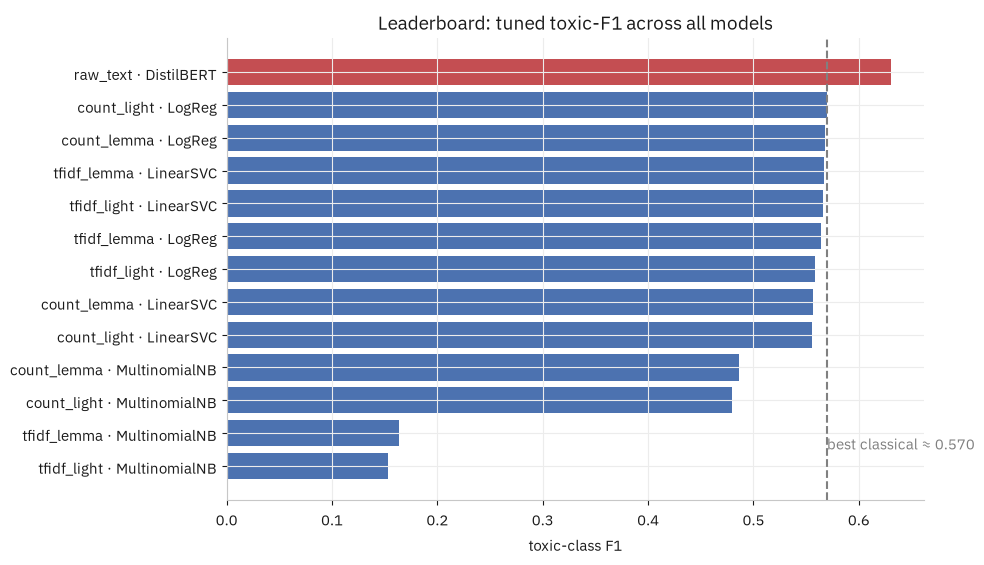

In [52]:
# plotting leaderboard
board = tuned_test_results_plus.copy()                    # tuned 12 + DistilBERT
board["name"] = board["matrix"] + " · " + board["model"]  # readable pipeline label
board = board.sort_values("f1_toxic")                     # ascending → best on top after barh
fig, ax = plt.subplots(figsize=(9, 6))
colours = ["#c44e52" if "raw_text" in m else "#4c72b0"    # highlight DistilBERT
           for m in board["matrix"]]
ax.barh(board["name"], board["f1_toxic"], color=colours)
bow_ceiling = board.loc[board["matrix"] != "raw_text", "f1_toxic"].max()   
ax.axvline(bow_ceiling, ls="--", color="grey")
ax.set_xlabel("toxic-class F1"); ax.set_title("Leaderboard: tuned toxic-F1 across all models")
ax.annotate(f"best classical ≈ {bow_ceiling:.3f}", (bow_ceiling, 0.5), color="grey")
print(f"BoW ceiling (best non-BERT tuned toxic-F1): {bow_ceiling:.4f}")

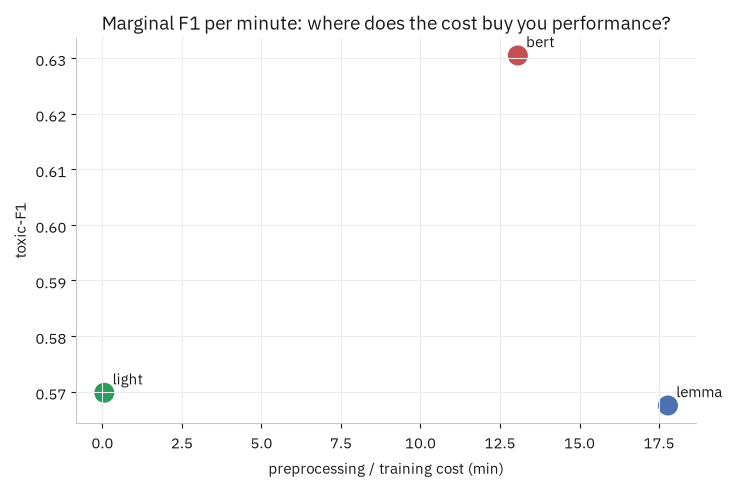

In [53]:
# cost vs performance plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(best["build_min"], best["f1_toxic"], s=180,    # one point per branch
           c=["#c44e52","#4c72b0","#2a9d5c"])
for _, r in best.iterrows():                              # label each branch
    ax.annotate(r["branch"], (r["build_min"], r["f1_toxic"]),
                xytext=(6,6), textcoords="offset points")
ax.set_xlabel("preprocessing / training cost (min)")
ax.set_ylabel("toxic-F1")
ax.set_title("Marginal F1 per minute: where does the cost buy you performance?")
plt.show()

### 5.7 Error analysis: confusion matrix of the tuned champion

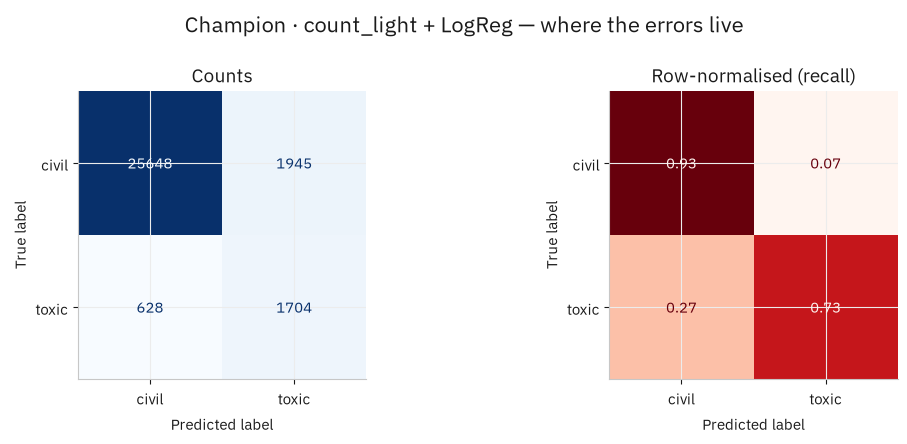

In [54]:
# performance evaluation of top lemma model
champ   = tuned[champ_key].best_estimator_
branch  = champ_key[0].split('_')[1]
y_pred  = champ.predict(df_model[f"{branch}_tokens"].to_numpy()[idx_test])     # predict on the held-out test-row slice

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))    

# panel 1: raw counts
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["civil", "toxic"],
    cmap="Blues", colorbar=False, ax=ax[0]
)
ax[0].set_title("Counts")

# panel 2: row-normalised = each row sums to 1, so diagonal = recall per class
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["civil", "toxic"],
    normalize="true",
    cmap="Reds", colorbar=False, ax=ax[1]
)
ax[1].set_title("Row-normalised (recall)")

fig.suptitle(f"Champion · {champ_key[0]} + {champ_key[1]} — where the errors live")
plt.tight_layout(); plt.show()

### 5.8 Prediction in action: scoring held-out comments

In [55]:
# predictive table
from IPython.display import display, clear_output

# pick the champion pipeline (best toxic-F1; LogReg because it has predict_proba)
BRANCH   = "lemma"
MATRIX   = f"tfidf_{BRANCH}"            # matching fitted vectoriser key in vec_configs
CLF_NAME = "LogReg"                     # LogReg gives a calibrated confidence score
TOKENCOL = f"{BRANCH}_tokens"           # pre-computed token lists already in df_model

vec = vec_configs[MATRIX]               # fitted vectoriser
clf = fitted[(MATRIX, CLF_NAME)]        # fitted classifier for that matrix

def predict_rows(pos):
    """pos = positional indices into df_model → tidy prediction DataFrame."""
    toks  = df_model[TOKENCOL].to_numpy()[pos]        # reuse stored tokens (no re-cleaning)
    Xnew  = vec.transform(toks)                       # same sparse feature space as training
    proba = clf.predict_proba(Xnew)[:, 1]             # P(toxic) per row
    pred  = (proba >= 0.5).astype(int)                # decision at the 0.5 threshold
    true  = df_model["label"].to_numpy()[pos] 
    text  = df_model["text"].to_numpy()[pos]
    return pd.DataFrame({
        "comment":   [t[:110] + ("…" if len(t) > 110 else "") for t in text],  # truncate for display
        "P(toxic)":  proba.round(3),
        "predicted": np.where(pred == 1, "🚩 TOXIC", "✅ civil"),
        "actual":    np.where(true == 1, "🚩 TOXIC", "✅ civil"),
        "hit":       np.where(pred == true, "✓", "✗"),
    })

def sample_batch(n=5, pool=idx_test, seed=None):
    rng = np.random.default_rng(seed)                 # seed=None gives fresh draw every run
    pos = rng.choice(pool, size=n, replace=False)     # n unique held-out rows
    return (predict_rows(pos).style
              .background_gradient(subset=["P(toxic)"], cmap="Reds", vmin=0, vmax=1)  # heat by risk
              .apply(lambda s: ["color:#c0392b" if v=="✗" else "color:#27ae60" for v in s],
                     subset=["hit"])                  # red misses, green hits
              .set_caption(f"{CLF_NAME} · {MATRIX} — {n} random held-out comments"))

sample_batch(5)     # re-run this line to cycle through the model's judgments

,comment,P(toxic),predicted,actual,hit
0,It is time for the working tax payers to drive a wooden stake through the black heart of this sad sick religio…,0.776000,🚩 TOXIC,🚩 TOXIC,✓
1,"or maybe there's a group...almost a community of sorts, who have wildly varying opinions, and enjoy the discus…",0.071000,✅ civil,🚩 TOXIC,✗
2,"""Excess profits"" raises a pink flag, if not a red one. The most direct and final solution to the excess pro…",0.034000,✅ civil,✅ civil,✓
3,Perhaps people are tiring of this...as am I. Perhaps people are recognizing the ganging-up mentality Perhap…,0.444000,✅ civil,✅ civil,✓
4,"Been there; done that, and far too often.",0.150000,✅ civil,✅ civil,✓


In [56]:
# flashcard version (animated)
def flashcards(n=6, pool=idx_test, pause=1.6, seed=None):
    rng = np.random.default_rng(seed)
    pos = rng.choice(pool, size=n, replace=False)
    df  = predict_rows(pos)
    for i in range(len(df)):
        clear_output(wait=True)                       # wipe previous card → animation effect
        display(pd.DataFrame(df.iloc[i]).T            # show one card at a time
                  .style.hide(axis="index")
                  .set_caption(f"Card {i+1}/{n}  —  press ▶ to replay"))
        time.sleep(pause)                             # dwell time per card

flashcards(6)

comment,P(toxic),predicted,actual,hit
plus a couple of stars...,0.090000,✅ civil,✅ civil,✓


comment,P(toxic),predicted,actual,hit
The cost of children is greatly overstated. Folks survive with kids on $30k a year income. I'm sure this famil…,0.047000,✅ civil,✅ civil,✓


comment,P(toxic),predicted,actual,hit
Unsanitary conditions in food preparation industry or underpaid help at up-scale restaurants on Maui?,0.097000,✅ civil,✅ civil,✓


comment,P(toxic),predicted,actual,hit
Do U get it?,0.235000,✅ civil,✅ civil,✓


comment,P(toxic),predicted,actual,hit
Jason Chaffetz is saying Mike Flynn failed to disclose payments from Russia and the White House (at best) refu…,0.264000,✅ civil,✅ civil,✓


comment,P(toxic),predicted,actual,hit
"By the time the State is done confiscating and redistributing the people's money, Alaskans won't be buying a…",0.415000,✅ civil,✅ civil,✓


<a id="conclusion"></a>
## 6. Conclusion

<b>Answering the Research Question</b>
> A comment's toxicity can be estimated as a probability, with moderate reliability: DistilBERT reaches a toxic-F1 of 0.630, and the best bag-of-words pipeline 0.570.

##### Final evaluation

| Approach | Best pipeline | Toxic-F1 | Macro-F1 | Preparation cost (minutes) |
|--|--|--|--|--|
| Bag-of-words, light cleaning | `count_light` + LogReg | 0.570 | 0.761 | 0.06 |
| Bag-of-words, lemmatised | `count_lemma` + LogReg | 0.568 | 0.759 | 17.78 |
| Contextual transformer | DistilBERT on raw `text` | <b>0.630</b> | <b>0.801</b> | 13.06 (GPU) |

* <b>Lemmatisation does not pay off:</b> 17.72 extra minutes changes toxic-F1 by −0.002, so light cleaning is sufficient for bag-of-words models (5.3.1, 5.6).
* <b>Linear models hit a vocabulary ceiling:</b> all tuned LogReg and LinearSVC pipelines land between 0.556 and 0.570. Their strongest signals are overt insults ("stupid", "idiot", "crap"), so they detect wording rather than intent (5.3.2).
* <b>Errors lean towards false alarms:</b> the champion catches 73% of toxic comments, but 53% of its 3,649 flags are civil (5.7).
* <b>Context adds signal:</b> DistilBERT lifts toxic-F1 by 0.061 (10.6% relative) despite training on 20,000 rows rather than about 120,000 (5.5, 5.6).

##### So what?
* P(toxic) is best used to <b>rank the moderation queue</b> for human review, not to remove comments automatically.
* A light bag-of-words LogReg is a cheap, interpretable first filter; DistilBERT justifies its GPU cost where missed toxicity is costly.

##### Limitations of study
* Results come from one stratified sample of 150,000 comments drawn from one of two data files.
* Binarising `toxicity` at 0.5 discards the severity gradient and the subtype scores.
* DistilBERT was fine-tuned for two epochs on a smaller training set, with validation loss already rising.
* Next steps: tune the decision threshold, fine-tune DistilBERT on the full training split, and model the subtype scores to measure severity by type of toxicity.

<a id="ref"></a>
## 7. References & Acknowledgements

I would like to thank Dr Chaitanya Rao, my course instructor, as well as Rachel Anastasi-Marais, our course teaching assistant, for their guidance as this project moved from tabular data into natural language processing.

<u>Data</u>
* Google Jigsaw. [Civil Comments dataset](https://huggingface.co/datasets/google/civil_comments). Hugging Face.
* Borkan, D., Dixon, L., Sorensen, J., Thain, N., & Vasserman, L. (2019). [Nuanced Metrics for Measuring Unintended Bias with Real Data for Text Classification](https://www.researchgate.net/publication/333060845_Nuanced_Metrics_for_Measuring_Unintended_Bias_with_Real_Data_for_Text_Classification). <i>Companion Proceedings of The 2019 World Wide Web Conference</i>.
* Jigsaw. (2019). [Jigsaw Unintended Bias in Toxicity Classification](https://www.kaggle.com/c/jigsaw-unintended-bias-in-toxicity-classification). Kaggle.

<u>Models, tools & libraries</u>
* Sanh, V., Debut, L., Chaumond, J., & Wolf, T. (2019). [DistilBERT, a distilled version of BERT: smaller, faster, cheaper and lighter](https://arxiv.org/abs/1910.01108). arXiv:1910.01108.
* Hugging Face. [Transformers](https://huggingface.co/docs/transformers).
* Pedregosa, F. et al. (2011). [Scikit-learn: Machine Learning in Python](https://scikit-learn.org/stable/). <i>Journal of Machine Learning Research</i>, 12, 2825–2830.
* Bird, S., Klein, E., & Loper, E. (2009). [Natural Language Processing with Python](https://www.nltk.org/). O'Reilly Media.
* Explosion. [spaCy: Industrial-strength Natural Language Processing](https://spacy.io/).
* pandas, NumPy, Matplotlib, Seaborn and WordCloud for data wrangling and visualisation; Google Colab for GPU fine-tuning.

###### Disclaimer:
The observations and take-aways expressed in this notebook are for the purposes of personal data exploration and analysis. Some outputs reproduce offensive language from the source dataset.